In [1]:
!pip install polars

import polars as pl

In [2]:
import os
import random
import sys
import cv2
import tqdm
import json
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:

!nvidia-smi

Tue Feb 17 05:34:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               On  |   00000000:D6:00.0 Off |                  Off |
| 30%   30C    P8             26W /  230W |       1MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
os.chdir('/workspace')

In [5]:
BASE_PATH = 'vindr_mammogram'
IMG_DIR = os.path.join(BASE_PATH, 'mammo_processed_merged1') 
csv_files = [f for f in os.listdir(IMG_DIR) if f.endswith('.csv')]

# Print results
if csv_files:
    print(f"Found {len(csv_files)} CSV file(s) in {IMG_DIR}:")
    for csv_file in csv_files:
        print(f"{csv_file}")
else:
    print(f"No CSV files found in {IMG_DIR}")


Found 1 CSV file(s) in vindr_mammogram/mammo_processed_merged1:
mammo_processed_merged.csv


In [6]:
df = pl.read_csv("vindr_mammogram/mammo_processed_merged1/mammo_processed_merged.csv")
df = df.to_pandas()
df["merged_image_path"] = (
    df["merged_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
density_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

df['density'] = df['cc_breast_density'].str[-1].map(density_mapping)
df.head()



,study_id,laterality,merged_image_path,cc_image_id,mlo_image_id,split,cc_image_path,mlo_image_path,has_cc_bbox,has_mlo_bbox,...,mlo_crop_coords,cc_breast_birads,mlo_breast_birads,cc_breast_density,mlo_breast_density,cc_finding_categories,mlo_finding_categories,cc_finding_birads,mlo_finding_birads,density
0,0025a5dc99fd5c742026f0b2b030d3e9,L,vindr_mammogram/mammo_processed_merged1/0025a5...,451562831387e2822923204cf8f0873e,2ddfad7286c2b016931ceccd1e2c7bbc,test,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 992, 2443)",BI-RADS 1,BI-RADS 1,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
1,0025a5dc99fd5c742026f0b2b030d3e9,R,vindr_mammogram/mammo_processed_merged1/0025a5...,fcf12c2803ba8dc564bf1287c0c97d9a,47c8858666bcce92bcbd57974b5ce522,test,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(11, 0, 1064, 2560)",BI-RADS 1,BI-RADS 1,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
2,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,L,vindr_mammogram/mammo_processed_merged1/0028fb...,3704f91985dcbc69f6ac2803523d1ecb,7fc1f1bb8bb1a7efaf7104e49c4d8b86,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 935, 2486)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
3,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,R,vindr_mammogram/mammo_processed_merged1/0028fb...,c4ce68631bf70949570ded31a3c69e60,16e58fc1d65fa7587247e6224ee96527,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(13, 0, 953, 2508)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
4,0034765af074f93ed33d5e8399355caf,L,vindr_mammogram/mammo_processed_merged1/003476...,68f09c18925a66ef2840d4a62f237b31,b664cf1e7c968896144a3a2005cd3eb4,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 961, 2802)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2


In [7]:
def get_combined_finding_5class(cc_findings, mlo_findings):
    """
    Optimized 5-class classification based on your requirements:
    
    PRIORITY ORDER (highest to lowest):
    1. Skin/Nipple/Architectural Distortion → Class 3 (always high suspicion)
    2. Mass + Calcifications together → Class 4 (highest suspicion combo)
    3. Mass only → Class 2
    4. Calcifications only → Class 1
    5. Pure Asymmetry only → DROP (-1)
    6. No Finding → Class 0
    
    Rationale:
    - Class 4 (Mass+Calc): Combined findings indicate complex malignant lesions
    - Class 3 (Arch Dist/Skin): Structural changes highly suspicious for cancer
    - Class 2 (Mass): Moderate-high suspicion, most common malignant finding
    - Class 1 (Calc): Variable suspicion, needs assessment
    - Class 0: Benign/Normal
    """
    # Parse findings
    if isinstance(cc_findings, str):
        cc_findings = eval(cc_findings) if cc_findings else []
    if isinstance(mlo_findings, str):
        mlo_findings = eval(mlo_findings) if mlo_findings else []
    
    cc_findings = cc_findings or []
    mlo_findings = mlo_findings or []
    all_findings = set(cc_findings + mlo_findings)
    
    # Remove 'No Finding' if other findings present
    if len(all_findings) > 1 and 'No Finding' in all_findings:
        all_findings.remove('No Finding')
    
    # Define finding groups
    high_suspicion_structural = {
        'Architectural Distortion',
        'Skin Thickening',
        'Skin Retraction',
        'Nipple Retraction'
    }
    
    asymmetry_findings = {
        'Focal Asymmetry',
        'Global Asymmetry',
        'Asymmetry'
    }
    
    # Check key findings
    has_mass = 'Mass' in all_findings
    has_calc = 'Suspicious Calcification' in all_findings
    has_structural = bool(all_findings & high_suspicion_structural)
    has_asymmetry = bool(all_findings & asymmetry_findings)
    has_lymph = 'Suspicious Lymph Node' in all_findings
    
    # Classification Logic
    
    # Class 0: No Finding
    if not all_findings or all_findings == {'No Finding'}:
        return 0
    
    # PRIORITY 1: Class 3 - High Suspicion Structural Changes
    # Any architectural distortion or skin/nipple changes
    if has_structural:
        return 3
    
    # PRIORITY 2: Class 4 - Combined Mass + Calcifications (Highest Suspicion)
    # This combination often indicates malignant lesions with microcalcifications
    if has_mass and has_calc:
        return 4
    
    # PRIORITY 3: Class 2 - Mass Only
    if has_mass:
        return 2
    
    # PRIORITY 4: Class 1 - Calcifications Only
    if has_calc:
        return 1
    
    # PRIORITY 5: Suspicious Lymph Node
    # Treat as high suspicion (often metastatic involvement)
    if has_lymph:
        return 3
    
    # PRIORITY 6: Pure Asymmetry Cases - DROP
    # These are ambiguous and mostly require additional imaging, not biopsys
    if has_asymmetry and len(all_findings) == 1:
        return 6  # Will be dropped
    
    # PRIORITY 7: Asymmetry + Other Findings
    # If asymmetry is combined with something else (rare), treat as high suspicion
    if has_asymmetry and len(all_findings) > 1:
        return 3
    
    # Fallback for unknown findings (shouldn't happen with your data)
    print(f"Warning: Unknown finding combination: {all_findings}")
    return 3  


df['finding'] = df.apply(
    lambda row: get_combined_finding_5class(row['cc_finding_categories'], row['mlo_finding_categories']),
    axis=1
)
df.drop(df[df['finding'] == -1].index, inplace=True)
df['finding'].value_counts()

finding
0    9032
2     490
6     189
1     132
3      95
4      61
Name: count, dtype: int64

In [8]:
inbreast_df = pd.read_csv("inbreast_data/INbreast_merged/merged_metadata.csv")
inbreast_df["merged_image_path"] = (
    inbreast_df["merged_image_path"]
    .str.replace("INbreast Release 1.0", "inbreast_data", regex=False)
    .str.replace("vindr_original_data", "inbreast_data", regex=False))
inbreast_df['birads'] = inbreast_df['birads'].replace({'4a': '4', '4b': '4', '4c': '4','6':'5'})
inbreast_df['label'] = (inbreast_df['birads'].astype(int) - 1).astype(int)
inbreast_df['density'] = 0
inbreast_df = inbreast_df.rename(columns={"patient_id": "study_id"})

inbreast_df.head(5)

,study_id,laterality,merged_image_path,cc_file_name,mlo_file_name,cc_image_path,mlo_image_path,birads,cc_roi_width,cc_roi_height,mlo_roi_width,mlo_roi_height,label,density
0,024ee3569b2605dc,L,inbreast_data/INbreast_merged/024ee3569b2605dc...,20588020,20588072,INbreast Release 1.0/INbreast_processed/205880...,INbreast Release 1.0/INbreast_processed/205880...,2,1557,3231,1674,3192,1,0
1,024ee3569b2605dc,R,inbreast_data/INbreast_merged/024ee3569b2605dc...,20587994,20588046,INbreast Release 1.0/INbreast_processed/205879...,INbreast Release 1.0/INbreast_processed/205880...,5,1535,3128,1775,3199,4,0
2,069212ec65a94339,L,inbreast_data/INbreast_merged/069212ec65a94339...,50994787,50994733,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,1,1226,2580,1340,3193,0,0
3,069212ec65a94339,R,inbreast_data/INbreast_merged/069212ec65a94339...,50994706,50994760,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,1,1128,2566,1177,3195,0,0
4,0b7396cdccacca82,L,inbreast_data/INbreast_merged/0b7396cdccacca82...,22670832,22670878,INbreast Release 1.0/INbreast_processed/226708...,INbreast Release 1.0/INbreast_processed/226708...,2,1627,2983,1598,3170,1,0


In [9]:
n_studies = inbreast_df['study_id'].nunique()
print("Total unique studies:", n_studies)


Total unique studies: 107


In [10]:
rows_per_study = inbreast_df.groupby('study_id').size()
rows_per_study.value_counts().sort_index()


1    27
2    80
Name: count, dtype: int64

In [11]:
studies_1 = rows_per_study[rows_per_study == 1].index
df_1 = inbreast_df[inbreast_df['study_id'].isin(studies_1)].copy()

df_1.head()


,study_id,laterality,merged_image_path,cc_file_name,mlo_file_name,cc_image_path,mlo_image_path,birads,cc_roi_width,cc_roi_height,mlo_roi_width,mlo_roi_height,label,density
6,0c735e8768d276b4,R,inbreast_data/INbreast_merged/0c735e8768d276b4...,50995789,50995762,INbreast Release 1.0/INbreast_processed/509957...,INbreast Release 1.0/INbreast_processed/509957...,2,1222,2837,1373,3008,1,0
7,11e6732579acf692,L,inbreast_data/INbreast_merged/11e6732579acf692...,53587599,53587572,INbreast Release 1.0/INbreast_processed/535875...,INbreast Release 1.0/INbreast_processed/535875...,2,2067,3719,2120,4031,1,0
10,1e4b534393d18753,R,inbreast_data/INbreast_merged/1e4b534393d18753...,50998349,50998322,INbreast Release 1.0/INbreast_processed/509983...,INbreast Release 1.0/INbreast_processed/509983...,1,971,2736,1521,3150,0,0
11,1e5c3af078f74b05,L,inbreast_data/INbreast_merged/1e5c3af078f74b05...,22614236,22614266,INbreast Release 1.0/INbreast_processed/226142...,INbreast Release 1.0/INbreast_processed/226142...,5,1390,2795,1457,2994,4,0
24,330e5fe16929eed4,R,inbreast_data/INbreast_merged/330e5fe16929eed4...,50996736,50996709,INbreast Release 1.0/INbreast_processed/509967...,INbreast Release 1.0/INbreast_processed/509967...,2,1860,2770,1852,3086,1,0


In [12]:
def birads_to_label(birads_category):
    """Convert BI-RADS categories to numerical labels 0-4 (for 5 classes)"""
    birads_num = int(birads_category.replace(" ", "")[-1])
    return birads_num - 1
df['label'] = df['cc_breast_birads'].apply(birads_to_label)

In [13]:
df['cc_breast_birads'].value_counts()

cc_breast_birads
BI-RADS 1    6703
BI-RADS 2    2337
BI-RADS 3     465
BI-RADS 4     381
BI-RADS 5     113
Name: count, dtype: int64

In [14]:
df['cc_breast_density'].value_counts()

cc_breast_density
DENSITY C    7645
DENSITY D    1350
DENSITY B     954
DENSITY A      50
Name: count, dtype: int64

In [15]:
data = df[df['split'] == 'training']
test_df = df[df['split'] == 'test']

In [16]:
from sklearn.model_selection import train_test_split


study_meta = (
    data
    .groupby('study_id')
    .agg({
        'cc_breast_birads': 'first',   # BI-RADS at study level
        'finding': 'first'             # finding already encoded as 0–4
    })
    .reset_index()
)


# -------------------------------------------------
study_meta['stratify_key'] = (
    study_meta['cc_breast_birads'].astype(str) + '_' +
    study_meta['finding'].astype(str)
)


train_studies, val_studies = train_test_split(
    study_meta['study_id'],
    test_size=0.1,
    stratify=study_meta['stratify_key'],
    random_state=423
)

train_df = data[data['study_id'].isin(train_studies)].copy()
val_df   = data[data['study_id'].isin(val_studies)].copy()


In [17]:
train_df['density'].value_counts()

density
2    5504
3     967
1     693
0      36
Name: count, dtype: int64

In [18]:
val_df['density'].value_counts()

density
2    611
3    113
1     71
0      4
Name: count, dtype: int64

In [19]:
train_df.shape

(7200, 27)

In [20]:
train_df.columns

Index(['study_id', 'laterality', 'merged_image_path', 'cc_image_id',
       'mlo_image_id', 'split', 'cc_image_path', 'mlo_image_path',
       'has_cc_bbox', 'has_mlo_bbox', 'merged_cc_bbox', 'merged_mlo_bbox',
       'original_cc_bbox', 'original_mlo_bbox', 'cc_crop_coords',
       'mlo_crop_coords', 'cc_breast_birads', 'mlo_breast_birads',
       'cc_breast_density', 'mlo_breast_density', 'cc_finding_categories',
       'mlo_finding_categories', 'cc_finding_birads', 'mlo_finding_birads',
       'density', 'finding', 'label'],
      dtype='str')

In [21]:
import numpy as np
import cv2
from PIL import Image
import torchvision.transforms as transforms
import random
import torch


def get_transforms(img_size=(512, 512)):
    """Enhanced mammogram preprocessing with medical imaging considerations"""
    
    train_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        
        transforms.RandomApply([
            transforms.RandomAffine(
                degrees=5,
                translate=(0.0, 0.0),
                scale=(0.9, 1.05),
                shear=6
            )
        ], p=0.6),
        
        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=(0.95, 1.05),
                contrast=(0.9, 1.1)
            )
        ], p=0.4),
        transforms.Lambda(lambda x: adjust_gamma(x, gamma=random.uniform(0.8, 1.2)) 
                         if random.random() < 0.4 else x),
        

        
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.2),
        
                # NOISE AUGMENTATIONS
        transforms.Lambda(lambda x: add_gaussian_noise(x, mean=0, std=random.uniform(0.001, 0.02)) 
                         if random.random() < 0.4 else x),
        
        transforms.Lambda(lambda x: add_speckle_noise(x, std=random.uniform(0.01, 0.03)) 
                         if random.random() < 0.2 else x),
        transforms.ToTensor(),
        
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    return train_transform, val_transform

def add_gaussian_noise(image, mean=0, std=0.02):
    """Gaussian noise - electronic noise in imaging sensors"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(mean, std, img_array.shape)
        noisy_img = np.clip(img_array + noise, 0, 1)
        return Image.fromarray((noisy_img * 255).astype(np.uint8))
    return image


def add_speckle_noise(image, std=0.03):
    """Speckle noise - multiplicative noise common in mammography"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(0, std, img_array.shape)
        noisy_img = img_array + img_array * noise
        return Image.fromarray((np.clip(noisy_img, 0, 1) * 255).astype(np.uint8))
    return image

def adjust_gamma(image, gamma=1.0):
    """
    Gamma correction - handles tissue density variation
    Gamma < 1 = brighter, > 1 = darker
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        gamma_corrected = np.power(img_array, gamma)
        return Image.fromarray((gamma_corrected * 255).astype(np.uint8))
    return image

In [22]:
import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pandas as pd
from PIL import Image
import os
from torchvision import transforms
import matplotlib.pyplot as plt
import random

import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pandas as pd
from PIL import Image
import os
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_v2_m, EfficientNet_V2_M_Weights
import time
import gc
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


class VinDrMammoDataset(Dataset):
    def __init__(self, dataframe, transform=None, mode='train'):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.mode = mode
        
        valid_study_ids = []
        study_combined_labels = []
        class_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
        problematic_studies = []
        
        for study_id in self.dataframe['study_id'].unique():
            rows = self.dataframe[self.dataframe['study_id'] == study_id]
            
            left_rows = rows[rows['laterality'] == 'L']
            right_rows = rows[rows['laterality'] == 'R']
            
            if left_rows.empty or right_rows.empty:
                problematic_studies.append((study_id, "Missing laterality"))
                continue
                
            left_path = left_rows.iloc[0]['merged_image_path']
            right_path = right_rows.iloc[0]['merged_image_path']
            
            if not os.path.exists(left_path):
                problematic_studies.append((study_id, f"Missing file: {left_path}"))
                continue
            if not os.path.exists(right_path):
                problematic_studies.append((study_id, f"Missing file: {right_path}"))
                continue
            
            valid_study_ids.append(study_id)
            
            label_L = left_rows.iloc[0]['label']
            label_R = right_rows.iloc[0]['label']
            combined_label = max(label_L, label_R)
            study_combined_labels.append(combined_label)
            
            class_counts[combined_label] += 1
        
        if problematic_studies:
            print(f"\n{mode.capitalize()} Dataset: {len(problematic_studies)} studies excluded due to missing sides or files:")
            for sid, reason in problematic_studies[:20]:
                print(f"   - {sid}: {reason}")
            if len(problematic_studies) > 20:
                print(f"   ... and {len(problematic_studies)-20} more.")
        
        self.study_ids = valid_study_ids
        self.study_combined_labels = study_combined_labels
        
        print(f"{mode.capitalize()} Dataset - Valid Studies: {len(self)}")
        print(f"Class Distribution: BI-RADS 1={class_counts[0]}, BI-RADS 2={class_counts[1]}, BI-RADS 3={class_counts[2]}, BI-RADS 4={class_counts[3]}, BI-RADS 5={class_counts[4]}")
    
    def __len__(self):
        return len(self.study_ids)
    
    def __getitem__(self, idx):
        study_id = self.study_ids[idx]
        rows = self.dataframe[self.dataframe['study_id'] == study_id]
        
        row_L = rows[rows['laterality'] == 'L'].iloc[0]
        row_R = rows[rows['laterality'] == 'R'].iloc[0]
        
        image_L = Image.open(row_L['merged_image_path']).convert('RGB')
        image_R = Image.open(row_R['merged_image_path']).convert('RGB')
        
        if self.transform:
            image_L_tensor = self.transform(image_L)
            image_R_tensor = self.transform(image_R)
        else:
            image_L_tensor = transforms.ToTensor()(image_L)
            image_R_tensor = transforms.ToTensor()(image_R)
        
        label_L = row_L['label']
        label_R = row_R['label']
        combined_label = max(label_L, label_R)
        
        finding_L = row_L.get('finding', 0)
        finding_R = row_R.get('finding', 0)
        finding = min(finding_L, finding_R) if finding_L != 0 and finding_R != 0 else (finding_L or finding_R or 0)
        
        density_L = row_L.get('density', 0)
        density_R = row_R.get('density', 0)
        density = max(density_L, density_R)
        
        return (
            image_R_tensor, image_L_tensor,
            torch.tensor(label_R, dtype=torch.long),
            torch.tensor(label_L, dtype=torch.long),
            torch.tensor(combined_label, dtype=torch.long),
            torch.tensor(finding, dtype=torch.long),
            torch.tensor(density, dtype=torch.long)
        )


def create_data_loaders(train_df, val_df, test_df, inbreast_df, batch_size=4, img_size=(512, 512)):
    train_transform, val_transform = get_transforms(img_size)
    
    train_dataset = VinDrMammoDataset(train_df, transform=train_transform, mode='train')
    val_dataset   = VinDrMammoDataset(val_df,   transform=val_transform,   mode='val')
    test_dataset  = VinDrMammoDataset(test_df,  transform=val_transform,   mode='test')
    inbreast_dataset = VinDrMammoDataset(inbreast_df, transform=val_transform, mode='inbreast')
    
    combined_labels = np.array(train_dataset.study_combined_labels)
    unique_classes, class_counts = np.unique(combined_labels, return_counts=True)
    
    β = 0.5 # 0.5–0.8 typical; 1.0 means full inverse, 0.0 means no balancing
    class_weights = (1.0 / class_counts) ** β
    class_weights = class_weights / class_weights.sum() * len(unique_classes)
    
    sample_weights = class_weights[combined_labels]
    print("Class counts:", dict(zip(unique_classes, class_counts)))
    print("Smoothed class weights:", np.round(class_weights, 3))
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                              num_workers=4, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=4, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False,
                              num_workers=4, pin_memory=True)
    inbreast_loader = DataLoader(inbreast_dataset, batch_size=1, shuffle=False,
                                 num_workers=4, pin_memory=True)
    
    return train_loader, val_loader, test_loader, inbreast_loader


batch_size = 4
train_loader, val_loader, test_loader, inbreast_loader = create_data_loaders(
    train_df, val_df, test_df, inbreast_df,
    batch_size=batch_size,
    img_size=(1024, 1024)
)

Train Dataset - Valid Studies: 3600
Class Distribution: BI-RADS 1=1823, BI-RADS 2=1113, BI-RADS 3=317, BI-RADS 4=264, BI-RADS 5=83

Val Dataset: 1 studies excluded due to missing sides or files:
   - dbca9d28baa3207b3187c4d07dc81a80: Missing laterality
Val Dataset - Valid Studies: 399
Class Distribution: BI-RADS 1=198, BI-RADS 2=135, BI-RADS 3=28, BI-RADS 4=31, BI-RADS 5=7
Test Dataset - Valid Studies: 1000
Class Distribution: BI-RADS 1=494, BI-RADS 2=319, BI-RADS 3=91, BI-RADS 4=73, BI-RADS 5=23

Inbreast Dataset: 27 studies excluded due to missing sides or files:
   - 0c735e8768d276b4: Missing laterality
   - 11e6732579acf692: Missing laterality
   - 1e4b534393d18753: Missing laterality
   - 1e5c3af078f74b05: Missing laterality
   - 330e5fe16929eed4: Missing laterality
   - 3be876aecfaad4ca: Missing laterality
   - 3e73f1c0670cfb0a: Missing laterality
   - 3f22cdda8da215e3: Missing laterality
   - 493155e17143edef: Missing laterality
   - 573747ee33ef6e5a: Missing laterality
   - 5d8

Visualizing training samples (paired R/L breasts):


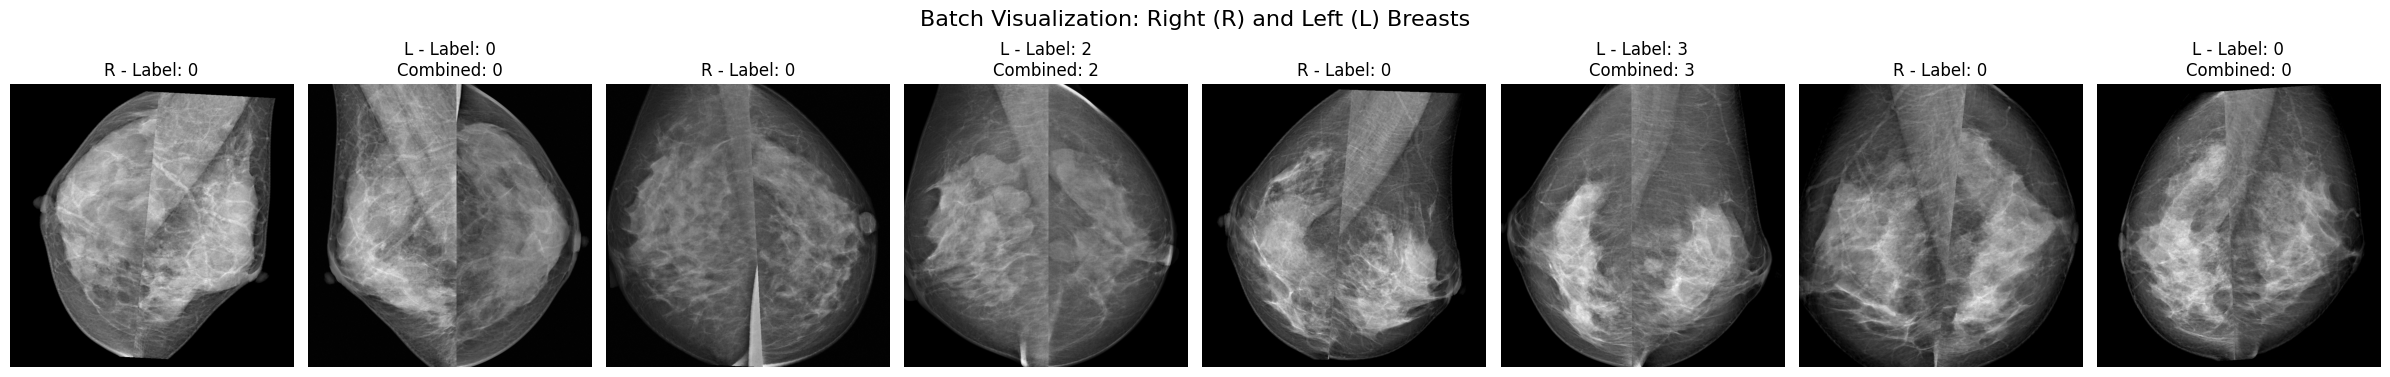


Visualizing validation samples (paired R/L breasts):


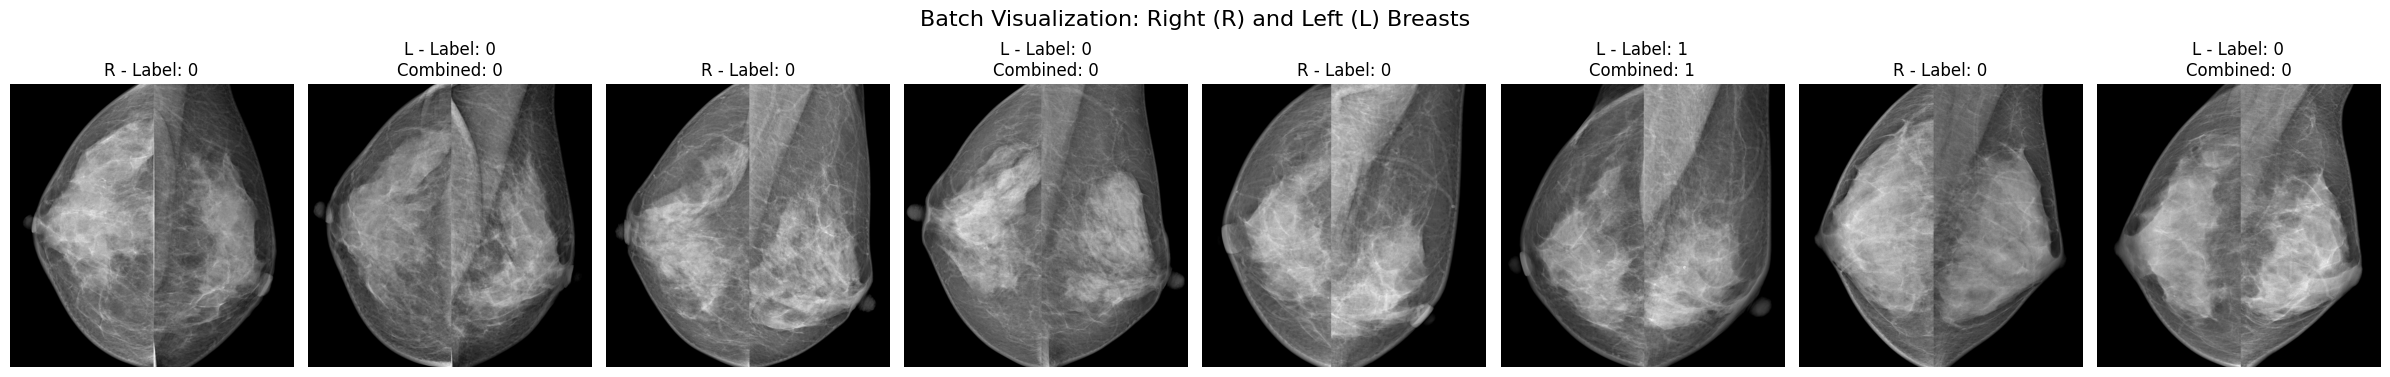

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_batch(batch, n_cols=4, apply_inverse_normalize=True):
    """
    Visualize a batch from the updated paired-breast dataset.
    Each sample contains: (image_R, image_L, label_R, label_L, combined_label, finding, density)
    We display R and L breasts side-by-side for each patient, with individual and combined labels.
    """
    image_R, image_L, label_R, label_L, combined_label, finding, density = batch
    
    batch_size = image_R.shape[0]
    # 2 images per patient (R and L) -> 2 * n_cols images per row
    images_per_row = 2 * n_cols
    n_rows = int(np.ceil(batch_size / n_cols))
    
    fig, axes = plt.subplots(n_rows, images_per_row, figsize=(3 * images_per_row, 4 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]  # Ensure 2D for consistency
    axes = axes.reshape(n_rows, images_per_row)
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i in range(batch_size):
        row = i // n_cols
        col_offset = 2 * (i % n_cols)
        
        # Process Right breast
        img_R = image_R[i].permute(1, 2, 0).cpu().numpy()
        if apply_inverse_normalize:
            img_R = img_R * std + mean
        img_R = img_R.clip(0, 1)
        img_R_gray = img_R.mean(axis=2)  # Convert to grayscale for mammography display
        
        axes[row, col_offset].imshow(img_R_gray, cmap='gray')
        axes[row, col_offset].set_title(f"R - Label: {label_R[i].item()}")
        axes[row, col_offset].axis('off')
        
        # Process Left breast
        img_L = image_L[i].permute(1, 2, 0).cpu().numpy()
        if apply_inverse_normalize:
            img_L = img_L * std + mean
        img_L = img_L.clip(0, 1)
        img_L_gray = img_L.mean(axis=2)
        
        axes[row, col_offset + 1].imshow(img_L_gray, cmap='gray')
        title = f"L - Label: {label_L[i].item()}\nCombined: {combined_label[i].item()}"
        axes[row, col_offset + 1].set_title(title)
        axes[row, col_offset + 1].axis('off')
    
    # Hide any unused subplots
    total_subplots = n_rows * images_per_row
    for j in range(2 * batch_size, total_subplots):
        r, c = divmod(j, images_per_row)
        axes[r, c].axis('off')
    
    plt.suptitle("Batch Visualization: Right (R) and Left (L) Breasts", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Visualize training batch
print("Visualizing training samples (paired R/L breasts):")
train_batch = next(iter(train_loader))
visualize_batch(train_batch)

# Visualize validation batch
print("\nVisualizing validation samples (paired R/L breasts):")
val_batch = next(iter(val_loader))
visualize_batch(val_batch)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AsymmetricOrdinalLoss(nn.Module):
    def __init__(self, num_classes=5, alpha=None, gamma=None, ordinal_weight=1.0, eps=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.eps = eps
        self.ordinal_weight = ordinal_weight
        
        if alpha is None:
            alpha = [0.10, 0.10, 0.30, 0.30, 0.20]
        alpha_tensor = torch.tensor(alpha, dtype=torch.float32)
        self.register_buffer("alpha", alpha_tensor / alpha_tensor.sum())
        
        if gamma is None:
            gamma = [1.5, 1.5, 2.5, 2.5, 2.0]
        gamma_tensor = torch.tensor(gamma, dtype=torch.float32)
        self.register_buffer("gamma", gamma_tensor)
        
        ordinal_matrix = torch.zeros(num_classes, num_classes)
        for i in range(num_classes):
            for j in range(num_classes):
                ordinal_matrix[i, j] = abs(i - j)
        self.register_buffer("ordinal_matrix", ordinal_matrix)
    
    def forward(self, logits, targets):
        targets = targets.long()
        
        log_probs = F.log_softmax(logits, dim=1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp().clamp(min=self.eps, max=1.0 - self.eps)
        
        alpha = self.alpha.to(logits.device)
        gamma = self.gamma.to(logits.device)
        alpha_t = alpha[targets]
        gamma_t = gamma[targets]
        
        focal_term = (1 - pt) ** gamma_t
        focal_loss = -alpha_t * focal_term * log_pt
        focal_loss = torch.nan_to_num(focal_loss, nan=0.0, posinf=0.0, neginf=0.0)
        
        probs = F.softmax(logits, dim=1)
        ordinal_matrix = self.ordinal_matrix.to(logits.device)
        target_ordinal_weights = ordinal_matrix[targets]
        ordinal_loss = (probs * target_ordinal_weights).sum(dim=1)
        
        total_loss = focal_loss + self.ordinal_weight * ordinal_loss
        
        return total_loss.mean()


aux_alpha = [0.12, 0.13, 0.25, 0.25, 0.25]  
aux_gamma = [2.0, 1.5, 0.0, 0.0, 0.0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = AsymmetricOrdinalLoss(
    num_classes=5,
    alpha=aux_alpha,
    gamma=aux_gamma,
    ordinal_weight=0.7
).to(device)

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class MammoDualViewModel(nn.Module):
    def __init__(self, backbone_class, backbone_weights=None, num_classes=5, feature_dim=512, dropout=0.3):
        super().__init__()
        
        self.shared_backbone = backbone_class(weights=backbone_weights)
        self.extractor, num_features = self._get_feature_extractor(self.shared_backbone)
        
        self.classifier = nn.Sequential(
            nn.Linear(num_features * 2, 512),
            # nn.BatchNorm1d(512),  
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            # nn.ReLU(inplace=True),
            nn.Dropout(dropout/2),
            
            nn.Linear(256, num_classes)
        )
    def _get_feature_extractor(self, model):
        if hasattr(model, "classifier") and hasattr(model.classifier, "in_features"):
            num_features = model.classifier.in_features
            model.classifier = nn.Identity()
            return model, num_features
        
        if hasattr(model, "classifier") and isinstance(model.classifier, nn.Sequential):
            num_features = model.classifier[-1].in_features
            model.classifier = nn.Identity()
            return model, num_features
        
        if hasattr(model, "fc"):
            num_features = model.fc.in_features
            model.fc = nn.Identity()
            return model, num_features
        
        if hasattr(model, "classifier") and hasattr(model, "features"):
            num_features = model.classifier.in_features
            model.classifier = nn.Identity()
            return model, num_features
        
        if hasattr(model, "head"):
            num_features = model.head.in_features
            model.head = nn.Identity()
            return model, num_features
        
        raise ValueError("Unsupported backbone architecture.")
    
    def forward(self, left, right):
        left_feat = self.extractor(left)
        right_feat = self.extractor(right)
        
        if left_feat.dim() == 4:
            left_feat = left_feat.mean([-2, -1])
        if right_feat.dim() == 4:
            right_feat = right_feat.mean([-2, -1])
        
        combined = torch.cat([left_feat, right_feat], dim=1)
        logits = self.classifier(combined)
        
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import autocast, GradScaler
from torchvision import models
import numpy as np
import os
import gc
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


def setup_optimizer(model, base_lr=1e-4, backbone_lr=1e-5, weight_decay=1e-4):
    
    backbone_params = list(model.extractor.parameters())
    classifier_params = list(model.classifier.parameters())
    
    param_groups = [
        {'params': backbone_params, 'lr': backbone_lr, 'weight_decay': weight_decay},
        {'params': classifier_params, 'lr': base_lr, 'weight_decay': weight_decay}
    ]
    
    optimizer = AdamW(param_groups, lr=base_lr, betas=(0.9, 0.999), eps=1e-8)
    
    return optimizer
    
models_config = [
    {
        'name': 'efficientnet_b3',
        'class': models.efficientnet_b3,
        'weights': models.EfficientNet_B3_Weights.DEFAULT
    },
    {
        'name': 'convnext_base',
        'class': models.convnext_base,
        'weights': models.ConvNeXt_Base_Weights.DEFAULT
    },
    # {
    #     'name': 'swin_v2_b',
    #     'class': models.swin_v2_b,
    #     'weights': models.Swin_V2_B_Weights.DEFAULT
    # }
]



def save_results(report, cm, save_path, dataset_name):
    os.makedirs(save_path, exist_ok=True)
    
    report_path = os.path.join(save_path, f"{dataset_name}_classification_report.txt")
    with open(report_path, "w") as f:
        f.write(report)
    
    cm_png_path = os.path.join(save_path, f"{dataset_name}_confusion_matrix.png")
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'],
                yticklabels=['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'])
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(cm_png_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Saved confusion matrix to {cm_png_path}")


class EarlyStopper:
    def __init__(self, patience=25, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
    
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        if score < self.best_score + self.min_delta:
            self.counter += 1
            return self.counter >= self.patience
        self.best_score = score
        self.counter = 0
        return False


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, train=True, use_amp=True):
    """
    Run one epoch of training or evaluation with mixed precision support.
    
    Args:
        model: The neural network model
        loader: DataLoader for the dataset
        criterion: Loss function
        optimizer: Optimizer (required if train=True)
        scaler: GradScaler for mixed precision (required if train=True and use_amp=True)
        train: Whether this is a training epoch
        use_amp: Whether to use automatic mixed precision
    """
    model.train() if train else model.eval()
    total_loss = 0.0
    preds_all, labels_all = [], []
    
    with torch.set_grad_enabled(train):
        for batch in loader:
            right_view, left_view, _, _, combined_label, _, _ = batch
            right_view = right_view.to(device, non_blocking=True)
            left_view = left_view.to(device, non_blocking=True)
            labels = combined_label.to(device, non_blocking=True)
            
            if train and use_amp:
                # Mixed precision training
                with autocast(device_type='cuda'):
                    outputs = model(right_view, left_view)
                    loss = criterion(outputs, labels)
                
                if optimizer is not None and scaler is not None:
                    optimizer.zero_grad()
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
            else:
                # Standard precision (for evaluation or when AMP is disabled)
                outputs = model(right_view, left_view)
                loss = criterion(outputs, labels)
                
                if train and optimizer is not None:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
            
            total_loss += loss.item() * right_view.size(0)
            preds = outputs.argmax(dim=1)
            preds_all.extend(preds.detach().cpu().numpy())
            labels_all.extend(labels.detach().cpu().numpy())
    
    num_samples = len(loader.dataset)
    avg_loss = total_loss / num_samples
    preds_np = np.array(preds_all)
    labels_np = np.array(labels_all)
    
    acc = np.mean(preds_np == labels_np) * 100
    f1_macro = f1_score(labels_np, preds_np, average='macro', zero_division=0)
    f1_weighted = f1_score(labels_np, preds_np, average='weighted', zero_division=0)
    
    report = classification_report(
        labels_np, preds_np, 
        target_names=['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'], 
        zero_division=0
    )
    cm = confusion_matrix(labels_np, preds_np)
    
    return avg_loss, acc, f1_macro, f1_weighted, report, cm

    
def train_and_evaluate(model_name, backbone_class, backbone_weights, train_loader, val_loader, test_loader, inbreast_loader, use_amp=True):
    """
    Train and evaluate a model with optional mixed precision training.
    
    Args:
        model_name: Name of the model architecture
        backbone_class: Backbone model class
        backbone_weights: Pre-trained weights for the backbone
        train_loader: Training data loader
        val_loader: Validation data loader
        test_loader: Test data loader (VinDr)
        inbreast_loader: Test data loader (InBreast)
        use_amp: Whether to use automatic mixed precision (default: True)
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MammoDualViewModel(backbone_class, backbone_weights).to(device)
    aux_alpha = [0.10, 0.10, 0.25, 0.30, 0.25]  
    aux_gamma = [1.5, 1.5, 0.5, 0.5, 0.5]
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    criterion = AsymmetricOrdinalLoss(
        num_classes=5,
        alpha=aux_alpha,
        gamma=aux_gamma,
        ordinal_weight=0.6
    ).to(device)
    
    optimizer = setup_optimizer(model)
    
    # Initialize GradScaler for mixed precision training
    scaler = GradScaler(device='cuda') if (use_amp and torch.cuda.is_available()) else None
    
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-6)
    
    stopper = EarlyStopper(patience=20, min_delta=0.001)
    
    save_dir = f"Thesis_updated_results/4_view_birads_1024/{model_name}"
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_model.pth")
    
    best_f1 = 0.0
    epochs = 60
    
    print(f"\n{'='*60}")
    print(f"Training {model_name} with {'mixed precision (AMP)' if use_amp and scaler else 'standard precision'}")
    print(f"{'='*60}\n")
    
    for epoch in range(epochs):
        train_loss, train_acc, train_f1_macro, train_f1_weighted, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, scaler, train=True, use_amp=use_amp
        )
        
        val_loss, val_acc, val_f1_macro, val_f1_weighted, val_report, val_cm = run_epoch(
            model, val_loader, criterion, train=False, use_amp=False  # No AMP for validation
        )
        
        scheduler.step(val_f1_macro)
        
        print(f"\nEpoch {epoch+1:2d}/{epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"Train: Loss={train_loss:.4f} | F1-Macro={train_f1_macro:.3f} | F1-Weighted={train_f1_weighted:.3f} | Acc={train_acc:.1f}%")
        print(f"Val:   Loss={val_loss:.4f} | F1-Macro={val_f1_macro:.3f} | F1-Weighted={val_f1_weighted:.3f} | Acc={val_acc:.1f}%")
        print(f"Val CM:\n{val_cm}")
        
        if val_f1_macro > best_f1:
            best_f1 = val_f1_macro
            torch.save({'model_state_dict': model.state_dict()}, best_model_path)
            print(f"New best model saved (F1-Macro: {val_f1_macro:.3f})")
        
        if stopper(val_f1_macro):
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print("\nFINAL EVALUATION")
    for loader, name in [(test_loader, "VinDr-Test"), (inbreast_loader, "InBreast-Test")]:
        loss, acc, f1_macro, f1_weighted, report, cm = run_epoch(
            model, loader, criterion, train=False, use_amp=False  # No AMP for evaluation
        )
        
        dataset_folder = "vindr" if "VinDr" in name else "inbreast"
        save_results(report, cm, os.path.join(save_dir, dataset_folder), name)
        
        print(f"\n{model_name.upper()} | {name}")
        print(f"Loss: {loss:.4f} | Acc: {acc:.1f}% | F1-Macro: {f1_macro:.3f} | F1-Weighted: {f1_weighted:.3f}")
        print(f"Classification Report:\n{report}")
        print(f"Confusion Matrix:\n{cm}")
    
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


if __name__ == "__main__":
    # Enable mixed precision training (set to False to disable)
    USE_MIXED_PRECISION = True
    
    for cfg in models_config:
        train_and_evaluate(
            cfg['name'],
            cfg['class'],
            cfg['weights'],
            train_loader,
            val_loader,
            test_loader,
            inbreast_loader,
            use_amp=USE_MIXED_PRECISION
        )

Using device: cuda

Training efficientnet_b3 with mixed precision (AMP)


Epoch  1/60 | LR: 1.00e-05
Train: Loss=1.1491 | F1-Macro=0.214 | F1-Weighted=0.247 | Acc=24.6%
Val:   Loss=0.8631 | F1-Macro=0.200 | F1-Weighted=0.233 | Acc=34.6%
Val CM:
[[ 11 184   1   2   0]
 [  6 123   1   5   0]
 [  0  26   1   1   0]
 [  0  29   0   2   0]
 [  0   4   0   2   1]]
New best model saved (F1-Macro: 0.200)

Epoch  2/60 | LR: 1.00e-05
Train: Loss=1.0662 | F1-Macro=0.209 | F1-Weighted=0.273 | Acc=27.9%
Val:   Loss=0.8596 | F1-Macro=0.210 | F1-Weighted=0.336 | Acc=29.6%
Val CM:
[[54 68 73  3  0]
 [21 49 62  3  0]
 [ 5 12 11  0  0]
 [ 4  5 18  4  0]
 [ 0  0  6  1  0]]
New best model saved (F1-Macro: 0.210)
